<a href="https://colab.research.google.com/github/jasonwong-lab/CancerMutationDetectionCourse/blob/main/CancerMutationDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Taster Lecture - Cancer Mutation Detection

*by Prof. Jason Wong*

This lecture aims to demonstrate how mutations are detected from next-generation sequencing data


## *** Package installation and downloads for workshop (~ 5 minutes)

1.   conda (for simple installation of packages)
2.   bwa (tools for sequence alignment)
3.   samtools (tools for processing sam & bam files)  
4.   IGV (tool for alignment visualisation)

**IMPORTANT：Every time you connect to Google Colab, you have to perform these set up steps again.**

In [ ]:
# Set working pathway to your own google drive (~ 1 min)
from google.colab import drive
drive.mount('/content/gdrive')

In [ ]:
# Install conda (~ 1 min). There will be a message saying that the session has crashed, but don't worry about this. This is due to the session restarting following conda installation.
!pip install -q condacolab
import condacolab
condacolab.install()

In [ ]:
# Install fastqc (~ 2 mins)
!conda install -y -c conda-forge -c bioconda \
  samtools=1.20 htslib=1.20 bwa

In [ ]:
# Install igv-notebook
import sys
print(sys.version, sys.executable)
!{sys.executable} -m pip install -U igv-notebook
import igv_notebook

## Create working directory

By default, the working directory will be My Drive/Cancer_course

In [ ]:
import os
try:
  os.mkdir("/content/gdrive/My Drive/Cancer_course/")
except FileExistsError:
  print("Cancer_course directory already exist. OK to continue")
try:
  os.mkdir("/content/gdrive/My Drive/Cancer_course/Datasets")
except FileExistsError:
  print("Datasets directory already exist. OK to continue")
os.chdir("/content/gdrive/My Drive/Cancer_course/")

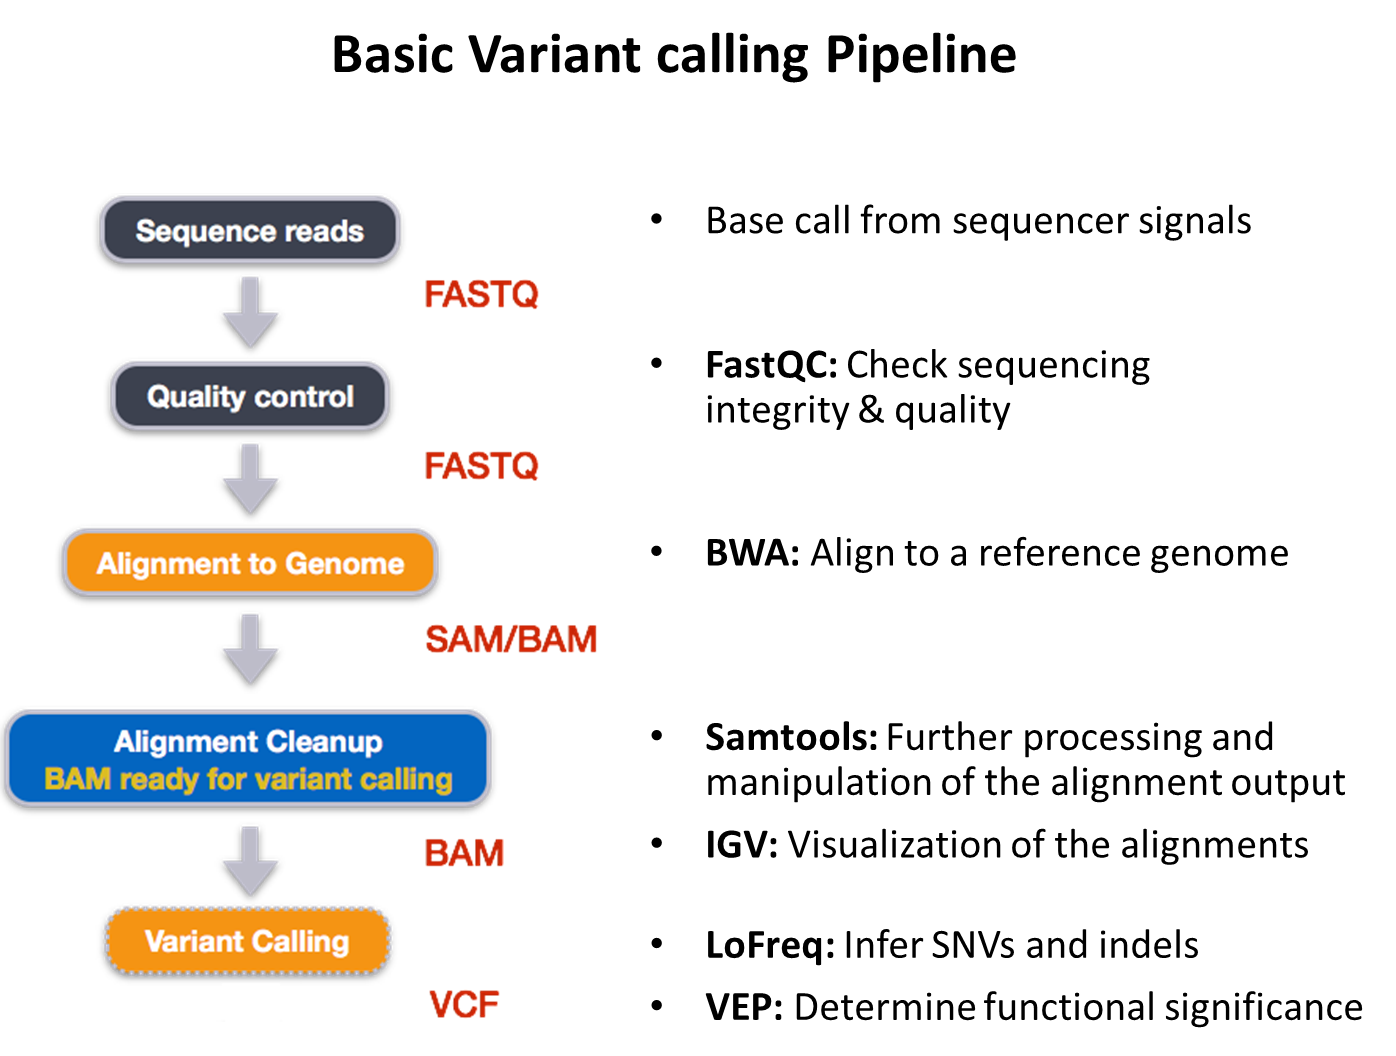

## Download reference database and sequencing data

In [ ]:
# Download data files
import os
os.chdir("/content/gdrive/My Drive/Cancer_course/")
if os.path.isfile("/content/gdrive/MyDrive/Cancer_course/DB_trunc/chr2.fa"):    # check if the file exist
  print("reference file already exit, OK to continue.")
else:
  !gdown 1LFRVhctNei--i61KFaXcIQkZHE9ivDLB  # download if file not exist
  #unzip fasta file
  !unzip DB_trunc.zip
  !rm DB_trunc.zip

In [ ]:
# Download necessary sequencing data
import os
os.chdir("/content/gdrive/My Drive/Cancer_course")

import os
if os.path.isfile("/content/gdrive/MyDrive/Cancer_course/Datasets/WXS_example_cancer_1.fq.gz"):    # check if the file exist
  print("file already exist, OK to continue.")
else:
 !wget -O Datasets_GXS.zip https://github.com/jasonwong-lab/HKU-Practical-Bioinformatics/raw/main/files/Datasets_GXS.zip
 !unzip -o Datasets_GXS.zip   # unzip file
 !rm Datasets_GXS.zip
 !wget -O Datasets/WXS_example_cancer_1.fq.gz https://github.com/jasonwong-lab/HKU-Practical-Bioinformatics/raw/main/files/WXS_example_cancer_1.fq.gz
 !wget -O Datasets/WXS_example_cancer_2.fq.gz https://github.com/jasonwong-lab/HKU-Practical-Bioinformatics/raw/main/files/WXS_example_cancer_2.fq.gz


# Check what files we have now
%cd /content/gdrive/MyDrive/Cancer_course/Datasets/
!ls -l

## NGS alignment

1.1. Alignment using BWA

1.2. Preparing files for visualisation using samtools

1.3. Viewing of aligned data using IGV

In [ ]:
# Check what datasets we have downloaded
%cd /content/gdrive/MyDrive/Cancer_course
!ls -l

%cd Datasets/
!ls -l

In [ ]:
# To look at the WXS_example fastq file type (head -n 12 to print first 12 lines):
!zcat < WXS_example_1.fq.gz | head -n 12

### Alignment using BWA

In [ ]:
# Look at the options for bwa and bwa mem
!bwa

In [ ]:
!bwa mem

In [ ]:
# Let's take a look at the database files
%cd /content/gdrive/My Drive/Cancer_course/DB_trunc

!ls -l

In [ ]:
# Make a directory to store the output file
%cd /content/gdrive/My Drive/Cancer_course/Datasets
!mkdir BAM

In [ ]:
# Do sequence alignment with the default options
!bwa mem -t 2 ../DB_trunc/chr2.fa ./WXS_example_1.fq.gz ./WXS_example_2.fq.gz > ./BAM/WXS_example.sam

!bwa mem -t 2 ../DB_trunc/chr2.fa ./WXS_example_cancer_1.fq.gz ./WXS_example_cancer_2.fq.gz > ./BAM/WXS_example_cancer.sam

### Preparing files for visualisation using samtools

In [ ]:
# Check the samtools command
!samtools

In [ ]:
# Check out some stats about our aligned file
!samtools flagstat ./BAM/WXS_example.sam
!echo
!samtools flagstat ./BAM/WXS_example_cancer.sam

In [ ]:
# Prepare the file for viewing on genome browser:
!samtools view -b ./BAM/WXS_example.sam |samtools sort > ./BAM/WXS_example_sorted.bam

!samtools index ./BAM/WXS_example_sorted.bam

!samtools view -b ./BAM/WXS_example_cancer.sam |samtools sort > ./BAM/WXS_example_cancer_sorted.bam

!samtools index ./BAM/WXS_example_cancer_sorted.bam

In [ ]:
# Look at the files that we have created
!ls -l ./BAM/

### Viewing of aligned data using IGV

In [ ]:
# Load track from local paths
import igv_notebook

igv_notebook.init()

b = igv_notebook.Browser(
    {
        "genome": "hg38",
        "locus": "chr2:47,782,081-47,807,953"
    }
)

b.load_track(
    {
        "name": "Normal",
        "path": "./BAM/WXS_example_sorted.bam",
        "indexPath": "./BAM/WXS_example_sorted.bam.bai",
        "format": "bam",
        "type": "alignment"
    })

b.load_track(
    {
        "name": "Cancer",
        "path": "./BAM/WXS_example_cancer_sorted.bam",
        "indexPath": "./BAM/WXS_example_cancer_sorted.bam.bai",
        "format": "bam",
        "type": "alignment"
    })